<a href="https://colab.research.google.com/github/SivaPanadi27/Telecom-Customer-Retention-ML-System/blob/main/EDA%20Part-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Overview:

This project focuses on building a Machine Learning model to help telecom companies identify customers who are likely to churn.

Telecom companies provide services like:
*   Mobile calls
*   Internet/network data
*   SMS services
*   Broadband (Wi-Fi)
*   TV/cable bundles

These companies earn revenue through customer subscription plans such as monthly and yearly packages.

When a customer stops using the services or switches to another provider, it results in revenue loss for the company. This situation is known as customer churn.

The main objective of this project is to build a model that can predict churn early, so companies can take proactive actions (offers, support, better plans) to retain customers and reduce losses.

# Step-1: Data Collection

To train our machine learning models, we collected the dataset from Google Dataset Search.


The dataset used is the Telecom Churn Dataset, which contains information about customers and whether they have churned (left the service) or continued using the service.


The dataset is available in CSV (Comma Separated Values) format, which stores data in a tabular structure with rows and columns.

The dataset contains 7043 customer records and 52 features.

#Step-2: Data Loading

After collecting the dataset, the next step is to load it into the working environment so that it can be analyzed and processed.

In this project, the dataset is loaded using the Pandas library, which is widely used for data manipulation and analysis in Python. Pandas allows datasets to be stored in a DataFrame, a tabular structure consisting of rows and columns.

In [2]:
#Code:
import pandas as pd
pd_df=pd.read_csv("Teleco_dataset.csv")
pd_df

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,Country,...,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code,Churn
0,72,4,19.44,NaN,NaN,51,San Mateo,4849,Two Year,United States,...,25,2191.15,0,486.00,0.0,2677.15,0,1,94403,0
1,27,59,45.62,NaN,NaN,27,Sutter Creek,3715,Month-to-Month,United States,...,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685,0
2,59,0,16.07,NaN,NaN,59,Santa Cruz,5092,Month-to-Month,United States,...,46,851.20,0,739.22,0.0,1590.42,0,0,95064,0
3,25,27,0.00,NaN,NaN,49,Brea,2068,One Year,United States,...,27,1246.40,30,0.00,0.0,1276.40,1,0,92823,0
4,31,21,17.22,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,United States,...,58,3563.80,0,998.76,0.0,4562.56,0,1,95117,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,33,12,10.67,NaN,NaN,53,Clayton,4847,Month-to-Month,United States,...,29,2878.75,0,309.43,0.0,3188.18,0,1,94517,0
7039,36,30,30.44,NaN,NaN,45,Nicolaus,5470,Two Year,United States,...,59,5655.45,0,1795.96,0.0,7451.41,0,1,95659,0
7040,57,24,4.51,NaN,NaN,74,Walnut Creek,4471,Two Year,United States,...,61,5175.30,0,275.11,0.0,5450.41,0,1,94596,0
7041,35,24,47.06,NaN,NaN,70,Valyermo,5445,Two Year,United States,...,30,1653.85,0,1411.80,0.0,3065.65,0,1,93563,0


#Step-3: Data Inspection



Data inspection is the process of examining the dataset to understand its structure, data types, missing values, and overall characteristics before performing further analysis or data cleaning.

This step helps identify potential issues in the dataset and provides an initial understanding of the data.

The following operations are performed during data inspection:

• Viewing sample records

• Checking dataset structure

• Understanding statistical summaries

• Identifying missing values

• Detecting duplicate rows

• Checking unique values in columns

In [3]:
# 1)head(): It returns us the first five rows of the dataset. If we need any specific number of rows then we can mention it as head(number_of_required)
pd_df.head()

# 2)tail(): It returns us the last five rows of the dataset. if we need any specific number of rows then we can mention it as tail(number_of_required)
pd_df.tail()

# 3)Info():It tells us the what columns are presennt in the dataset their datatype and non-null count
pd_df.info()

# 4)Describe(): It gives us the stastical outcomes of the  numerical columns in dataset such as mean, std etc...
pd_df.describe()

# 5)Describe(): It gives us the stastical outcomes of the categorical columns in dataset
pd_df.describe(include='object')

# 6) Columns: It returns the columns present in the dataset
pd_df.columns

#7)Shape: It returns the matrix of rows and columns present in the dataset
pd_df.shape

# 8)value_counts:It is used on target variable to get to know whether the dataset is balanced or imblanced
pd_df["Churn"].value_counts()

# 9) Missing values
pd_df.isnull().sum()

# 10) Duplicate rows
pd_df.duplicated().sum()

# 11) Unique values in each column
pd_df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Avg Monthly GB Download            7043 non-null   int64  
 2   Avg Monthly Long Distance Charges  7043 non-null   float64
 3   Churn Category                     1869 non-null   object 
 4   Churn Reason                       1869 non-null   object 
 5   Churn Score                        7043 non-null   int64  
 6   City                               7043 non-null   object 
 7   CLTV                               7043 non-null   int64  
 8   Contract                           7043 non-null   object 
 9   Country                            7043 non-null   object 
 10  Customer ID                        7043 non-null   object 
 11  Customer Status                    7043 non-null   objec

,0
Age,62
Avg Monthly GB Download,50
Avg Monthly Long Distance Charges,3584
Churn Category,5
Churn Reason,20
Churn Score,81
City,1106
CLTV,3438
Contract,3
Country,1


#Insights from Data Inspection:

1) From the info() function we observed that:
  

* The dataset contains both numerical and categorical columns.
*  We have observed or understood that there are missing values present in Churn Category, Churn Reason, Internet Type, Offers

2) From the shape() function we observed that the dataset contains 7043 rows and 52 columns.

3) From isnull().sum() we found that missing values are present in the following columns:

   • Churn Category

   • Churn Reason

   • Internet Type

   • Offers

   The rest of the columns do not contain missing values.

4) From value_counts() on the Churn column we observed that:


*  The dataset is imbalanced.
*  The ratio between non-churn and churn customers is approximately 2.7 : 1.


5) From duplicated().sum() we have observed that the dataset contains 0 duplicate rows.

6) From the describe() function we obtained statistical summaries for:


*   Numerical columns such as:count, mean, median (50%), standard deviation, minimum, maximum, 25% and 75%.

* Categorical Columns: top, count,freq


   

# Data Cleaning:

It is a process of preparing raw data such that it can be accurate ,consistent and usable for analysis and model training.

In real world data sets the data is messy.it contains:
*  Missing Values
*  Duplicate Values
*   Wrong Entires
*   Incorrest data types
*   Irrevalant Columns etc..


And If we Train Machine Learning Models With Unclean data then there is a possiblity of:

*   Model  learning incorrect patterns
*   Giving Poor Predictions
*   Treat errors as menaingful information(noise)
*   it can lead to over-fitting

To aviod this we perform data cleaning before going through EDA and Model Building.

In Data Cleaning these are the major steps we go through:


1.   Removing Data Leakages
2.   Handling Missing Values

1.   Handling Duplicate Values
2.   Fixing Data Types

1.   Removing Irrelevant Features



2.   Feature Consistency Checking













In [4]:
#1) Remove Data Leakages
pd_df= pd_df.drop(["Churn Reason","Churn Category","Churn Score","Customer Status"],axis=1)
pd_df

'''Data leakage occurs when the model has access to information that would not be available at the time of prediction.

  Because of such columns, the model may show very high accuracy during training, but it does not actually learn meaningful patterns and performs poorly on
  unseen data.

  Example:
  In this churn dataset, the columns Churn Category, Churn Reason, and Churn Score directly reveal why a customer churned.
  Since these columns contain information about the final outcome, they must be removed before training the model.'''


'Data leakage occurs when the model has access to information that would not be available at the time of prediction.\n\n  Because of such columns, the model may show very high accuracy during training, but it does not actually learn meaningful patterns and performs poorly on\n  unseen data.\n\n  Example:\n  In this churn dataset, the columns Churn Category, Churn Reason, and Churn Score directly reveal why a customer churned.\n  Since these columns contain information about the final outcome, they must be removed before training the model.'

In [5]:
#2)Handling Duplicate Rows

print(pd_df.duplicated().sum())

'''From the above check, we observe that there are no duplicate rows present in the dataset.
   Therefore, no duplicate records need to be removed.'''

0


'From the above check, we observe that there are no duplicate rows present in the dataset.\n   Therefore, no duplicate records need to be removed.'

In [6]:
#3)Handling Missing Values
pd_df.isnull().sum() #It gives us how many missing values are present in a column.

'''This function shows the number of missing values present in each column.
   From the output, we observe that two columns contain missing values:
    Internet Type (1526 missing values)
    Offer (3877 missing values)
    Next, we check the data type of these columns.'''
pd_df[["Internet Type","Offer"]].dtypes

#As we can see there are missing values more so we will fill them[imputation]. Ans as these are categorical features we will with mode or unknown category.
pd_df[["Internet Type","Offer"]].nunique()
pd_df[["Internet Type","Offer"]].mode()

"""Usually, categorical missing values are replaced using the mode.
   However, in this case, the Offer column contains around 50% missing values (3877 out of 7043).
  If we replace them with the mode (Offer B), it may bias the model.
  Therefore, instead of filling with the mode, we replace them with a new category."""
pd_df["Offer"].fillna("No offer",inplace=True)
pd_df["Internet Type"].fillna("Unknown",inplace=True)
print(pd_df.isnull().sum())

'''Now there are no missing values remaining in the dataset'''

Age                                  0
Avg Monthly GB Download              0
Avg Monthly Long Distance Charges    0
City                                 0
CLTV                                 0
Contract                             0
Country                              0
Customer ID                          0
Dependents                           0
Device Protection Plan               0
Gender                               0
Internet Service                     0
Internet Type                        0
Lat Long                             0
Latitude                             0
Longitude                            0
Married                              0
Monthly Charge                       0
Multiple Lines                       0
Number of Dependents                 0
Number of Referrals                  0
Offer                                0
Online Backup                        0
Online Security                      0
Paperless Billing                    0
Partner                  

/tmp/ipykernel_1302/618098830.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pd_df["Offer"].fillna("No offer",inplace=True)
/tmp/ipykernel_1302/618098830.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

'Now there are no missing values remaining in the dataset'

In [7]:
#4) Fixing Data Types
print(pd_df.dtypes)

""" From the above output, we observe that the data types of the columns are already in the correct format, so no further changes are required."""

Age                                    int64
Avg Monthly GB Download                int64
Avg Monthly Long Distance Charges    float64
City                                  object
CLTV                                   int64
Contract                              object
Country                               object
Customer ID                           object
Dependents                             int64
Device Protection Plan                 int64
Gender                                object
Internet Service                       int64
Internet Type                         object
Lat Long                              object
Latitude                             float64
Longitude                            float64
Married                                int64
Monthly Charge                       float64
Multiple Lines                         int64
Number of Dependents                   int64
Number of Referrals                    int64
Offer                                 object
Online Bac

' From the above output, we observe that the data types of the columns are already in the correct format, so no further changes are required.'

In [8]:
#5)Remove Irrelevant or Uncessary Columns
pd_df.nunique()
'''We could remove country,State,quarter as there are only one unique and model cannot learn
anything from it'''
pd_df.drop(["Country","State","Quarter"],axis=1,inplace=True)
pd_df.columns
pd_df.nunique()

'''Even Customer ID and Zip Code are unnecessary columns for model training.
   Customer ID is a unique identifier for each customer and does not help the model learn any patterns related to churn.
   Zip Code represents geographical location information, but it has many unique values and does not directly contribute to predicting whether a customer
   will churn or not.
   Therefore, these columns are removed from the dataset.'''
pd_df.drop(["Customer ID","Zip Code"],axis=1,inplace=True)
print(pd_df.columns)

'''Latitude and Longitude represent the geographical location of customers.
   These features are mainly useful when performing geographical or location-based analysis.
   Since this project focuses on predicting customer churn based on telecom usage and customer behavior, these columns do not provide meaningful information for the model.
   Therefore, Latitude and Longitude are removed from the dataset.'''
pd_df.drop(["Latitude","Longitude","Lat Long","City"],axis=1,inplace=True)

pd_df.nunique()
pd_df.shape

Index(['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges',
       'City', 'CLTV', 'Contract', 'Dependents', 'Device Protection Plan',
       'Gender', 'Internet Service', 'Internet Type', 'Lat Long', 'Latitude',
       'Longitude', 'Married', 'Monthly Charge', 'Multiple Lines',
       'Number of Dependents', 'Number of Referrals', 'Offer', 'Online Backup',
       'Online Security', 'Paperless Billing', 'Partner', 'Payment Method',
       'Phone Service', 'Population', 'Premium Tech Support',
       'Referred a Friend', 'Satisfaction Score', 'Senior Citizen',
       'Streaming Movies', 'Streaming Music', 'Streaming TV',
       'Tenure in Months', 'Total Charges', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Refunds', 'Total Revenue',
       'Under 30', 'Unlimited Data', 'Churn'],
      dtype='object')


(7043, 39)

In [9]:
# 6) Feature Consistency Check

# Checking categorical columns
for col in pd_df.select_dtypes(include=['object']):
    print(col, ":", pd_df[col].unique())


print("Unique values for Binary Columns:")

Binary_List = [
"Gender","Dependents","Married","Multiple Lines","Online Security",
"Paperless Billing","Online Backup","Device Protection Plan",
"Premium Tech Support","Streaming TV","Streaming Movies",
"Streaming Music","Unlimited Data","Partner","Phone Service"
]

for col in Binary_List:
    print(col, ":", pd_df[col].unique())


'''Insight:
1. From the above check we observed that the categorical columns contain consistent category and  values and no unexpected categories are present.
2. From the above check we observed that the Binary  columns contain consistent Binary values and no unexpected categories are present.

'''

Contract : ['Two Year' 'Month-to-Month' 'One Year']
Gender : ['Female' 'Male']
Internet Type : ['Fiber Optic' 'Unknown' 'DSL' 'Cable']
Offer : ['No offer' 'Offer B' 'Offer E' 'Offer A' 'Offer D' 'Offer C']
Payment Method : ['Bank Withdrawal' 'Credit Card' 'Mailed Check']
Unique values for Binary Columns:
Gender : ['Female' 'Male']
Dependents : [0 1]
Married : [1 0]
Multiple Lines : [0 1]
Online Security : [0 1]
Paperless Billing : [0 1]
Online Backup : [1 0]
Device Protection Plan : [1 0]
Premium Tech Support : [0 1]
Streaming TV : [0 1]
Streaming Movies : [1 0]
Streaming Music : [1 0]
Unlimited Data : [1 0]
Partner : [1 0]
Phone Service : [1 0]


'Insight:\n1. From the above check we observed that the categorical columns contain consistent category and  values and no unexpected categories are present.\n2. From the above check we observed that the Binary  columns contain consistent Binary values and no unexpected categories are present.\n\n'

EDA:

EDA stands for Exploratory Data Analysis.It is used to understand the patterns or relationship between the features or between the features and target before building the model.

EDA is classified into 4 types:




1.   Target Analysis



1.   Univariate Analysis
2.   Bi-Variate Analysis
1.   Multi-Variate Analysis






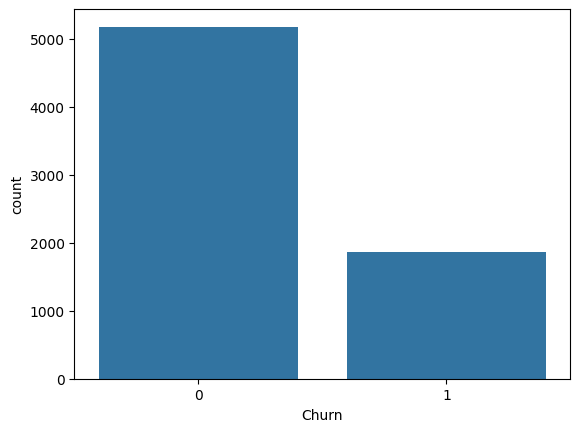

In [10]:
#Method:1 Target Analysis: It means to understand the distribution of the target.

pd_df["Churn"].value_counts()

pd_df["Churn"].value_counts(normalize=True)*100

'''Insight:
From the above results we observed that the dataset is moderately imbalanced, where the number of customers who stayed is higher than those who churned.

Due to this imbalance, the model may become biased towards the majority class.

To avoid this issue we follow two steps:

1) Instead of relying only on Accuracy, we consider other evaluation metrics such as Precision, Recall, and F1 Score.

Reason:
If a model predicts all customers as "Stayed", the accuracy would still be around 73%, which would be misleading.

2) We can also use class_weight="balanced" in Logistic Regression to give higher importance to the minority class (Churn).
'''
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Churn",data=pd_df)
plt.show()


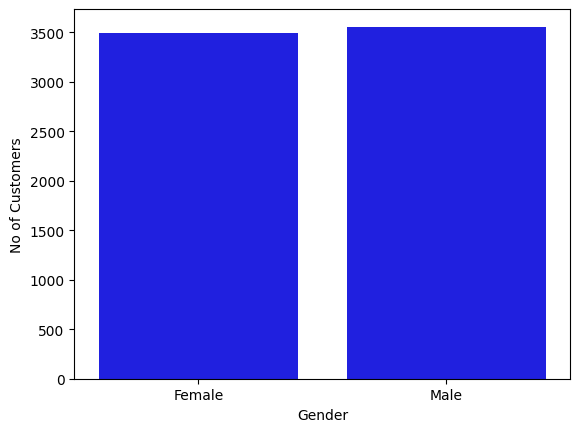

count     7043
unique       2
top       Male
freq      3555
Name: Gender, dtype: object


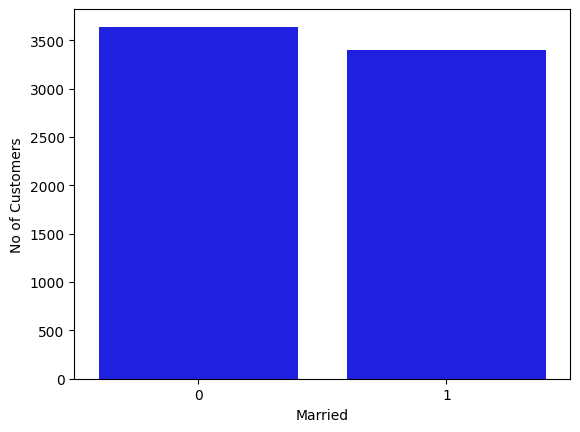

count    7043.000000
mean        0.483033
std         0.499748
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Married, dtype: float64


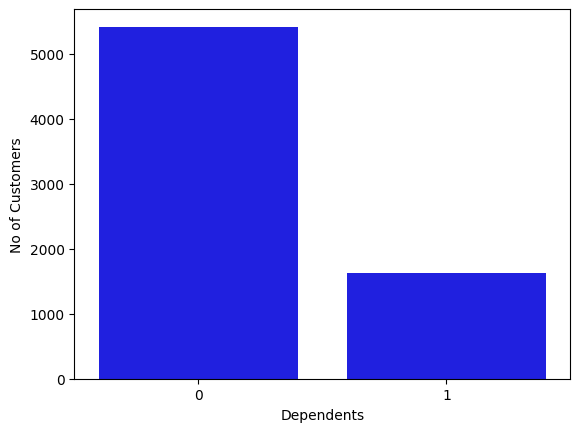

count    7043.000000
mean        0.231010
std         0.421508
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Dependents, dtype: float64


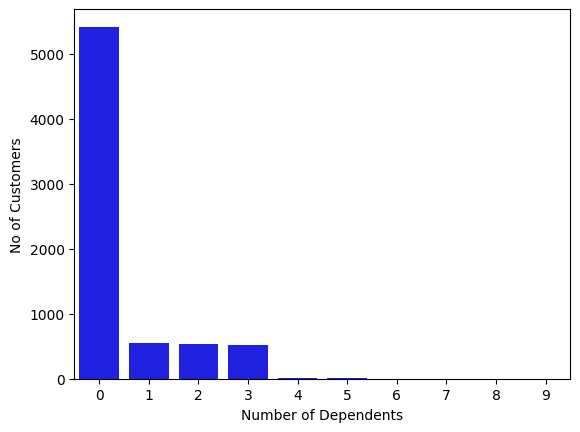

count    7043.000000
mean        0.468692
std         0.962802
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         9.000000
Name: Number of Dependents, dtype: float64


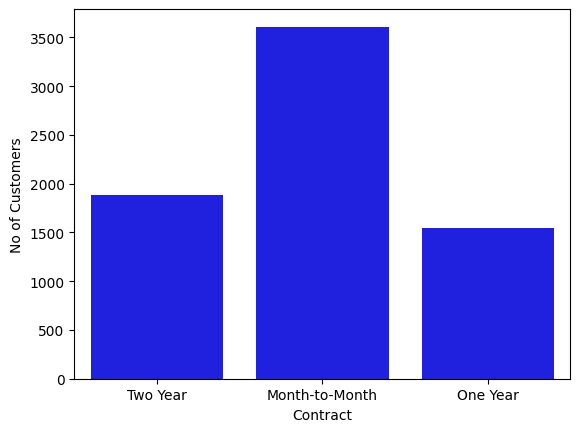

count               7043
unique                 3
top       Month-to-Month
freq                3610
Name: Contract, dtype: object


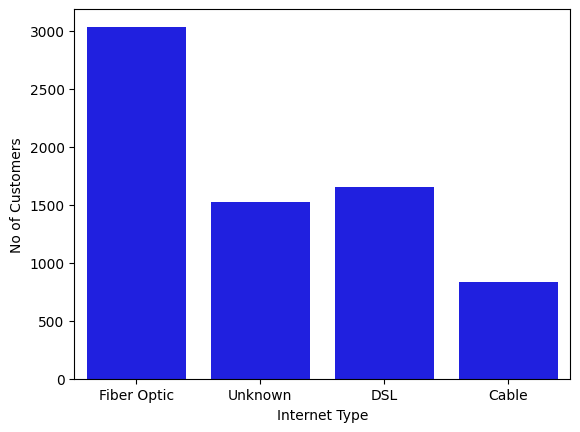

count            7043
unique              4
top       Fiber Optic
freq             3035
Name: Internet Type, dtype: object


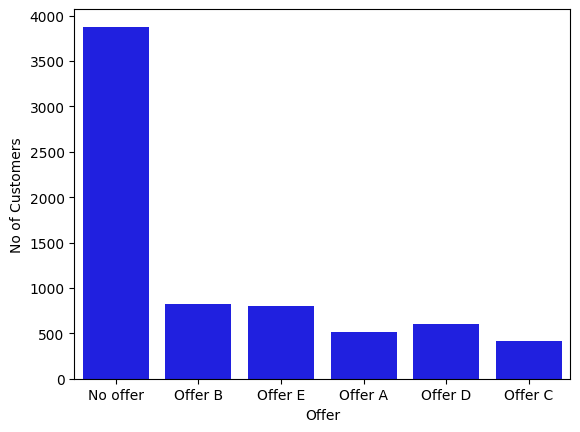

count         7043
unique           6
top       No offer
freq          3877
Name: Offer, dtype: object


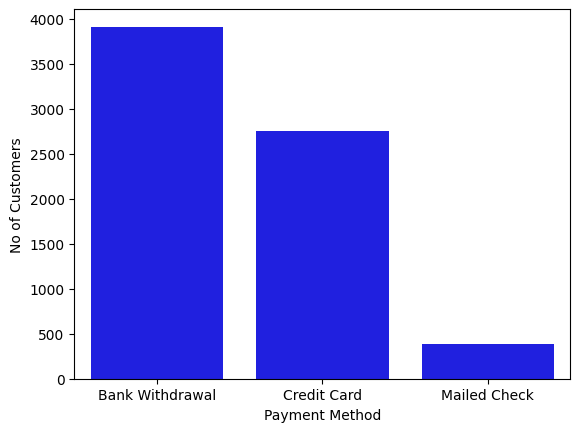

count                7043
unique                  3
top       Bank Withdrawal
freq                 3909
Name: Payment Method, dtype: object


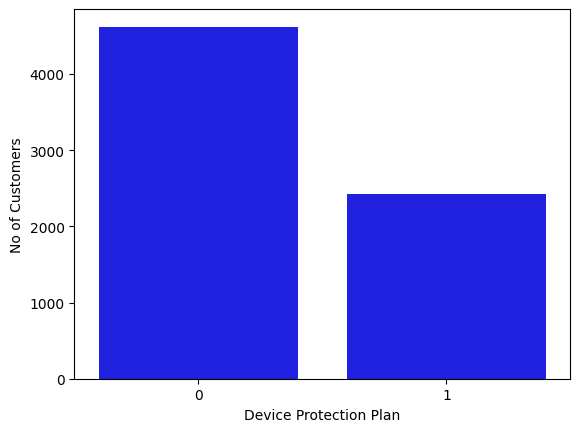

count    7043.000000
mean        0.343888
std         0.475038
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Device Protection Plan, dtype: float64


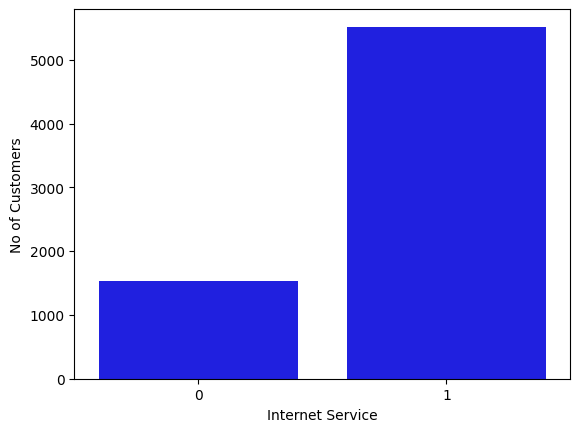

count    7043.000000
mean        0.783331
std         0.412004
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Internet Service, dtype: float64


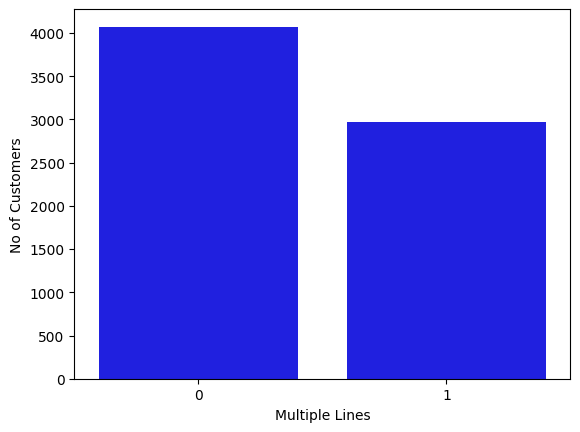

count    7043.000000
mean        0.421837
std         0.493888
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Multiple Lines, dtype: float64


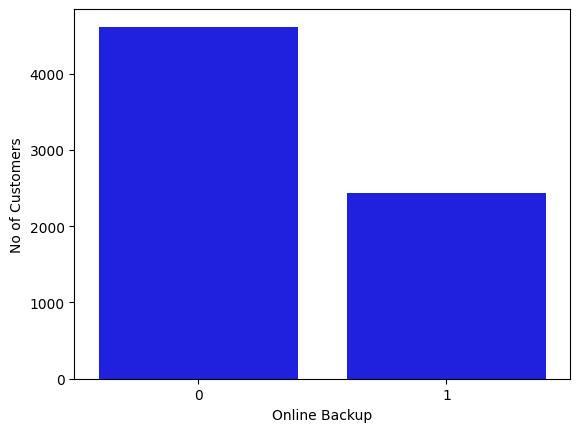

count    7043.000000
mean        0.344881
std         0.475363
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Online Backup, dtype: float64


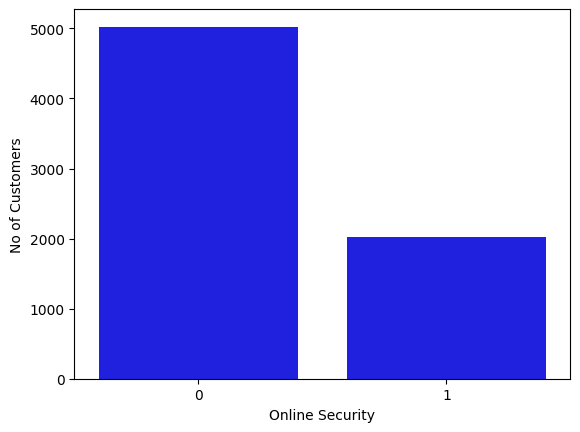

count    7043.000000
mean        0.286668
std         0.452237
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Online Security, dtype: float64


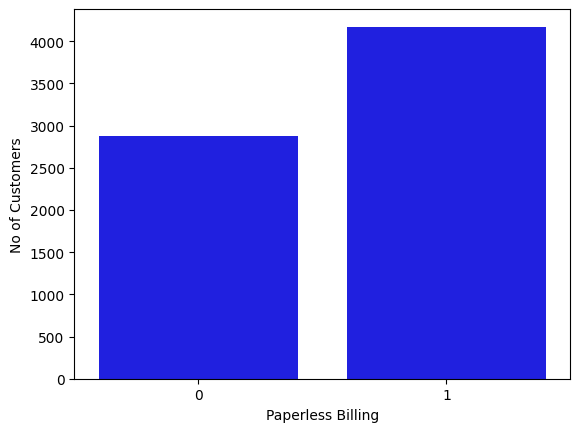

count    7043.000000
mean        0.592219
std         0.491457
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Paperless Billing, dtype: float64


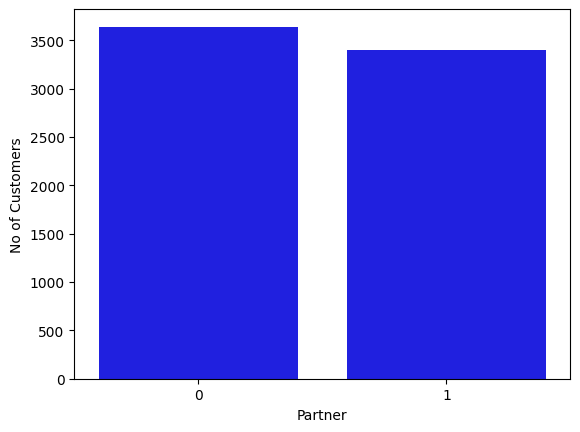

count    7043.000000
mean        0.483033
std         0.499748
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Partner, dtype: float64


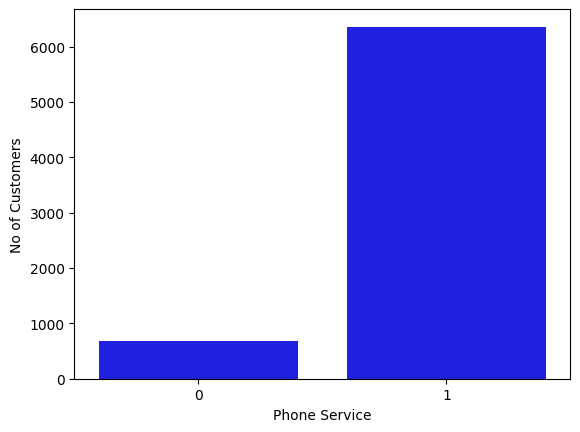

count    7043.000000
mean        0.903166
std         0.295752
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Phone Service, dtype: float64


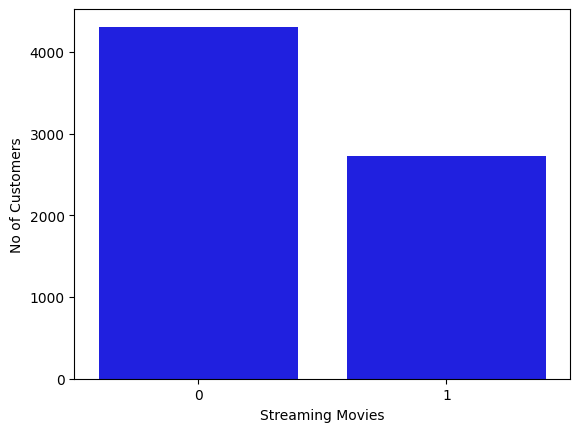

count    7043.000000
mean        0.387903
std         0.487307
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Streaming Movies, dtype: float64


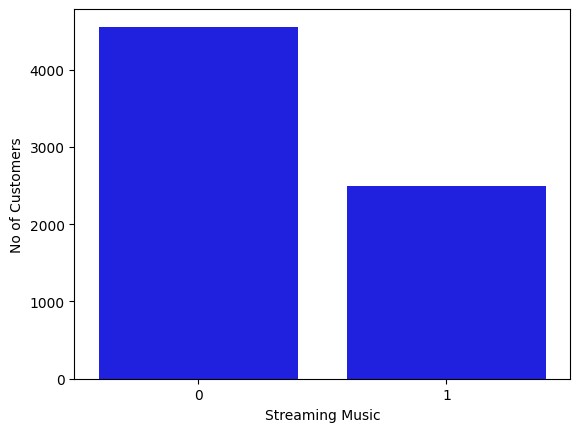

count    7043.000000
mean        0.353259
std         0.478016
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Streaming Music, dtype: float64


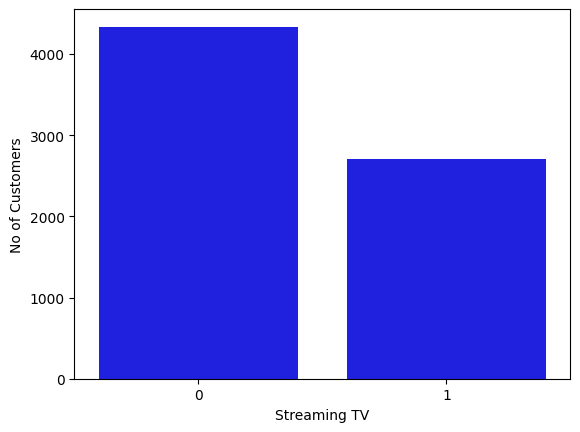

count    7043.000000
mean        0.384353
std         0.486477
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Streaming TV, dtype: float64


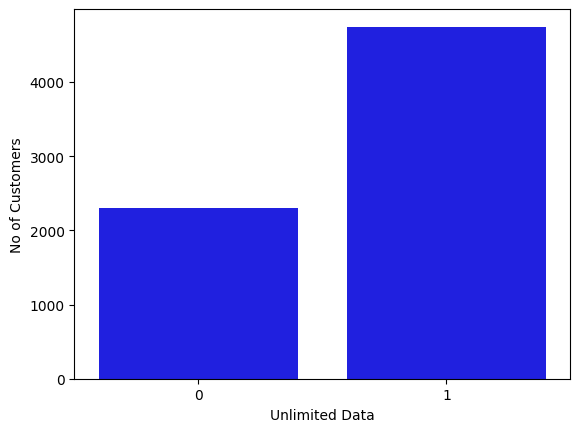

count    7043.000000
mean        0.673719
std         0.468885
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Unlimited Data, dtype: float64


In [11]:
#Method:2 Univariate analysis: It means analyzing one variable(column)at a time to understand it's characterstics.

Categorical_List=['Gender','Married','Dependents','Number of Dependents',"Contract","Internet Type","Offer","Payment Method","Device Protection Plan",
                  "Internet Service","Multiple Lines","Online Backup","Online Security","Paperless Billing","Partner","Phone Service","Streaming Movies",
                  "Streaming Music","Streaming TV","Unlimited Data"]

for i in Categorical_List:
  sns.countplot(x=i,data=pd_df,color='blue')
  plt.xlabel(i)
  plt.ylabel("No of Customers")
  plt.show()
  print(pd_df[i].describe(include="object"))






# Insights from Categorical / Binary Features:

1.**Gender**


*   The dataset contains two categories: Male and Female.
*   The most frequent category is Male (3555 customers).

*   The distribution appears fairly balanced between male and female customers, so gender is not heavily biased in the dataset.



2.**Married**


*  This feature contains binary values (0 and 1) indicating whether a customer is married.

*  The mean is around 0.48, which suggests that almost half of the customers are married and half are not.


*   This indicates a balanced distribution.

3.**Dependents**



*   The mean value is 0.23, which indicates that most customers do not have
dependents.

*   Only a smaller portion of customers have dependents.





4.**Number of Dependents**

*  The values range from 0 to 9 dependents.

*   The median is 0, indicating that the majority of customers do not have dependents.
*   Only a small number of customers have multiple dependents.

5.**Contract**
*   There are three contract types.

*   The most common contract type is Month-to-Month (3610 customers).

*  This suggests that many customers prefer short-term flexible contracts rather than long-term commitments.

6.**Internet Type**

*  The dataset contains multiple internet service types.

*  The most common type is Fiber Optic (3035 customers).

*   This indicates that a large number of customers use high-speed internet services.

7.**Offer**

*  There are six types of promotional offers.


*  The most frequent category is No Offer (3877 customers).




*   This suggests that more than half of the customers are not using any promotional offers.


  









8.**Payment Method**

*  There are three payment methods used by customers.

* The most common payment method is Bank Withdrawal (3909 customers).

*  This indicates that many customers prefer automatic bank payments.

9.**Device Protection Plan**

*   This feature indicates whether a customer has a device protection plan.



*   The mean value is around 0.34, which suggests that most customers do not subscribe to this service.




10.**Internet Service**


*   The mean value is 0.78, which indicates that a large number of customers have internet services enabled.









11.**Multiple Lines**

*  The mean value is 0.42, which suggests that less than half of the customers use multiple phone lines.


12.**Online Backup**

*   The mean value is 0.34, indicating that most customers do not use online backup services.

13.**Online Security**
*   The mean value is 0.28, which suggests that only a small portion of customers subscribe to online security services.

14.**Paperless Billing**
*   The mean value is 0.59, indicating that more than half of the customers prefer paperless billing.

15.**Partner**
*  The mean value is 0.48, which shows that the number of customers with and without partners is nearly balanced.

16.**Phone Service**

*  The mean value is 0.90, indicating that almost all customers use phone services.


17.**Streaming Movies**

* The mean value is 0.38, which suggests that only some customers subscribe to movie streaming services.

18.**Streaming Music**

*   The mean value is 0.35, which indicates that music streaming services are used by a smaller portion of customers.






19.**Streaming TV**


*  The mean value is 0.38, which shows that TV streaming services are used by less than half of the customers.

20.**Unlimited Data**
*   The mean value is 0.67, indicating that a majority of customers have unlimited data plans.

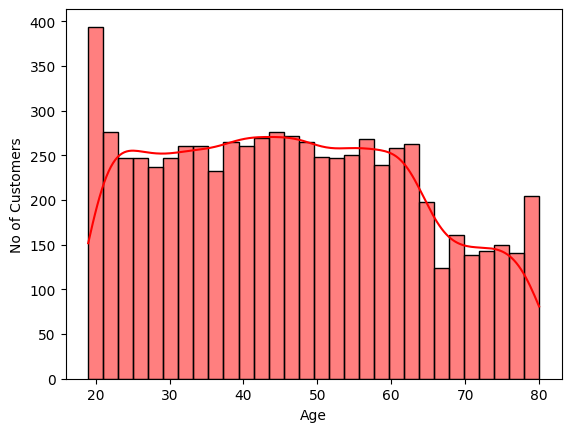

count    7043.000000
mean       46.509726
std        16.750352
min        19.000000
25%        32.000000
50%        46.000000
75%        60.000000
max        80.000000
Name: Age, dtype: float64


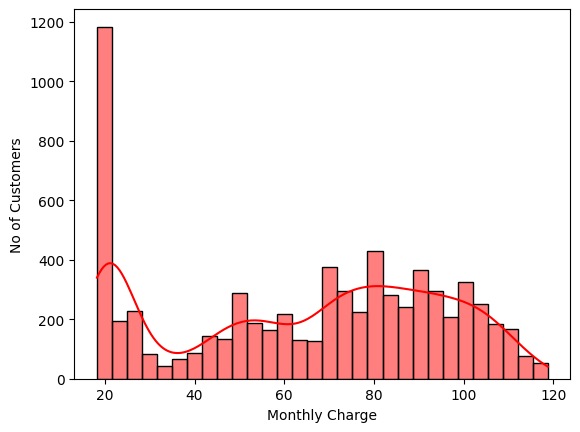

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charge, dtype: float64


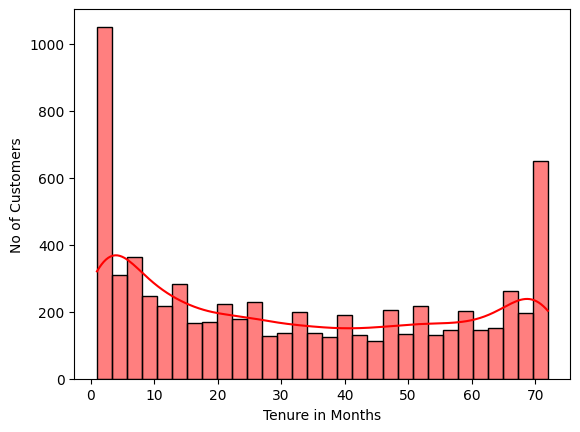

count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure in Months, dtype: float64


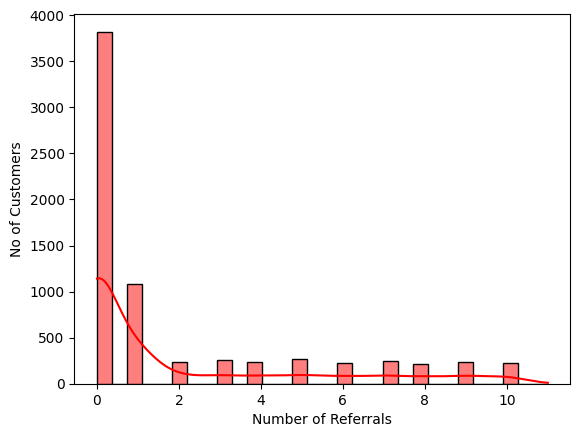

count    7043.000000
mean        1.951867
std         3.001199
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        11.000000
Name: Number of Referrals, dtype: float64


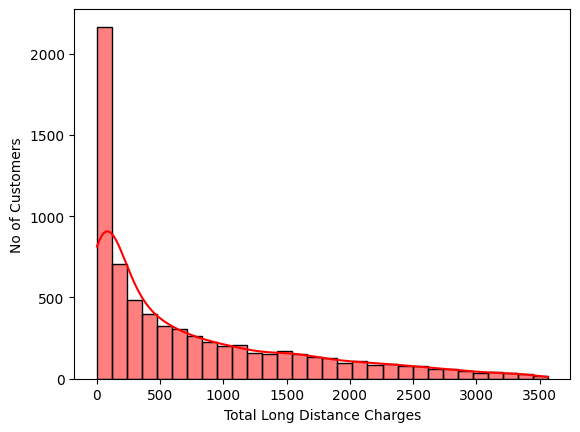

count    7043.000000
mean      749.099262
std       846.660055
min         0.000000
25%        70.545000
50%       401.440000
75%      1191.100000
max      3564.720000
Name: Total Long Distance Charges, dtype: float64


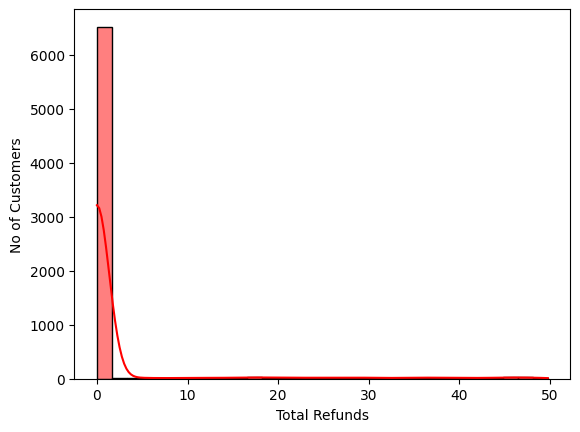

count    7043.000000
mean        1.962182
std         7.902614
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        49.790000
Name: Total Refunds, dtype: float64


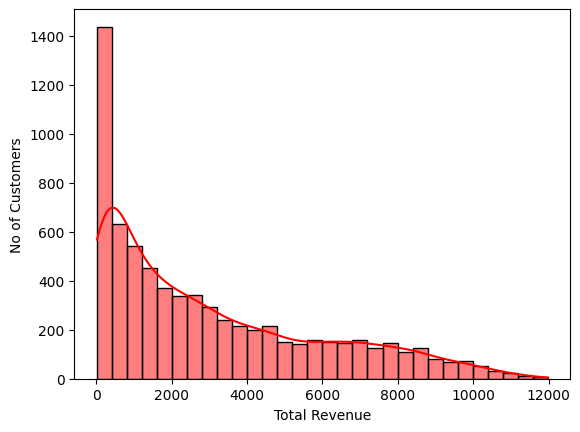

count     7043.000000
mean      3034.379056
std       2865.204542
min         21.360000
25%        605.610000
50%       2108.640000
75%       4801.145000
max      11979.340000
Name: Total Revenue, dtype: float64


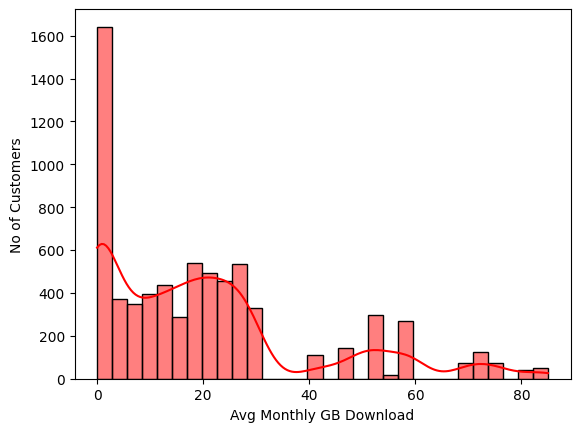

count    7043.000000
mean       20.515405
std        20.418940
min         0.000000
25%         3.000000
50%        17.000000
75%        27.000000
max        85.000000
Name: Avg Monthly GB Download, dtype: float64


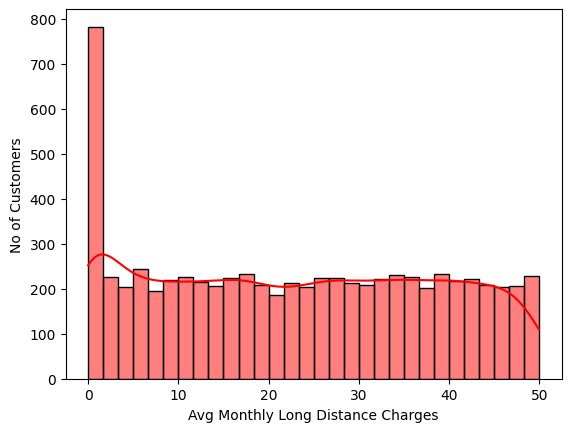

count    7043.000000
mean       22.958954
std        15.448113
min         0.000000
25%         9.210000
50%        22.890000
75%        36.395000
max        49.990000
Name: Avg Monthly Long Distance Charges, dtype: float64


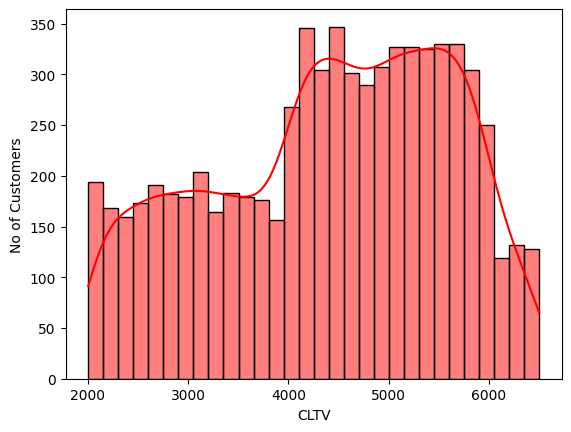

count    7043.000000
mean     4400.295755
std      1183.057152
min      2003.000000
25%      3469.000000
50%      4527.000000
75%      5380.500000
max      6500.000000
Name: CLTV, dtype: float64


In [12]:
Numeric_List=["Age","Monthly Charge","Tenure in Months","Number of Referrals",'Total Long Distance Charges','Total Refunds','Total Revenue','Avg Monthly GB Download',
'Avg Monthly Long Distance Charges',"CLTV",]
for i in Numeric_List:
  sns.histplot(x=i,data=pd_df,bins=30,kde=True,color='red')
  plt.xlabel(i)
  plt.ylabel("No of Customers")
  plt.show()
  print(pd_df[i].describe())






# Univariate Insights for Numerical Features

1.**Age**


*   The age ranges from 19 to 80 years, which is a reasonable range.

*  The mean (46.5) and median (46) are almost similar, indicating the distribution is approximately symmetric.

*   The middle 50% of customers fall between 32 and 60 years.

*   This suggests that most customers belong to the middle age group.


2.**Monthly Charges**

*  Monthly charges range from 18 to 118, which is reasonable for telecom plans.

*  The median (70.35) is greater than the mean (64.76), indicating a slightly negatively skewed distribution.

*  A noticeable portion of customers pay lower charges around 20–40, while another group pays higher charges between 70–110.

*  This indicates the presence of different plan categories (basic and premium plans).

3.**Tenure in Months**

* Tenure ranges from 1 to 72 months, meaning customers have stayed from 1 month to 6 years.

* The mean (32.38) is slightly greater than the median (29), indicating a slight positive skew.


* Most customers fall between 9 and 55 months, suggesting a mix of new and long-term customers.

4.**Number of Referrals**


* The number of referrals ranges from 0 to 11.

* The median is 0, indicating that most customers do not refer others.

* The mean (1.95) is higher than the median, showing a right-skewed distribution, meaning a small number of customers refer multiple people.

5.**Total Long Distance Charges**

* The charges range from 0 to 3564, showing a large variation in long-distance usage.

* The mean (749) is greater than the median (401), indicating a positively skewed distribution.
* This suggests that most customers have lower long-distance charges, while a few customers incur very high charges.

6.**Total Refunds**

* Refund values range from 0 to around 49.

* The median is 0, indicating that most customers do not receive refunds.

*  The mean is slightly higher due to a small number of customers receiving refunds, resulting in positive skewness.

7.**Total Revenue**


*   Total revenue ranges from 21 to around 11979.


*  The mean (3034) is greater than the median (2108), indicating positive skewness.
   

8.**Avg Monthly GB Download**

*  The values range from 0 to 85 GB per month.

*   The mean (20.5) is slightly higher than the median (17), indicating right skewness.

*  This suggests that most customers use moderate internet data, while a smaller group consumes very high data.

Age : 
        count       mean        std   min   25%   50%   75%   max
Churn                                                            
0      5174.0  45.344414  16.276025  19.0  32.0  45.0  58.0  80.0
1      1869.0  49.735688  17.604893  19.0  35.0  50.0  65.0  80.0


Monthly Charge : 
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
0      5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
1      1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


Tenure in Months : 
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
0      5174.0  37.591225  24.085029  1.0  15.0  38.0  61.0  72.0
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


Number of Referrals : 
        count      mean       std  min  25%  50%  75%   max
Churn                                                 

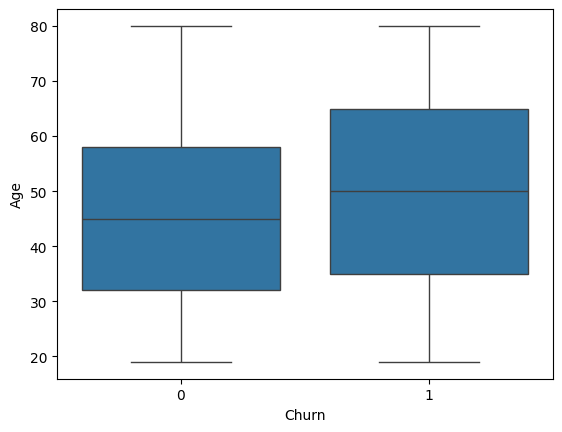

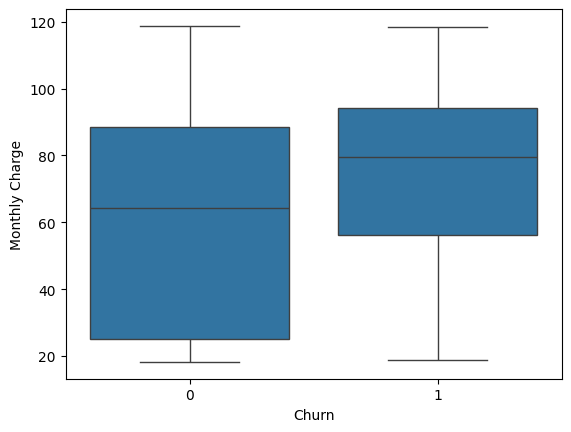

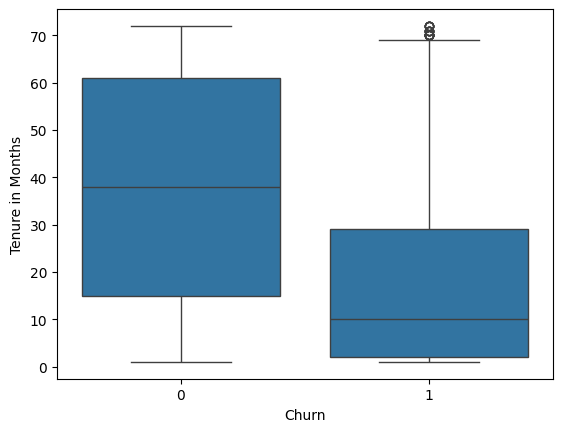

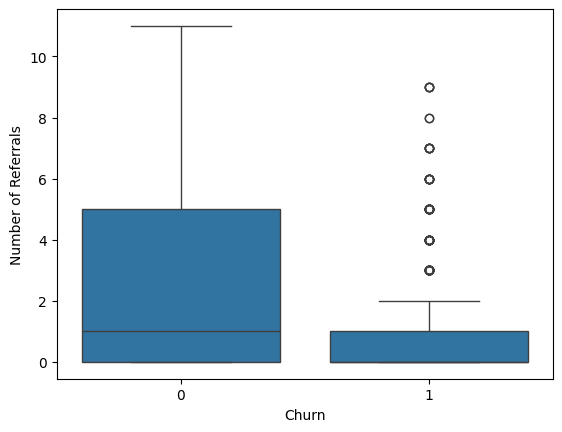

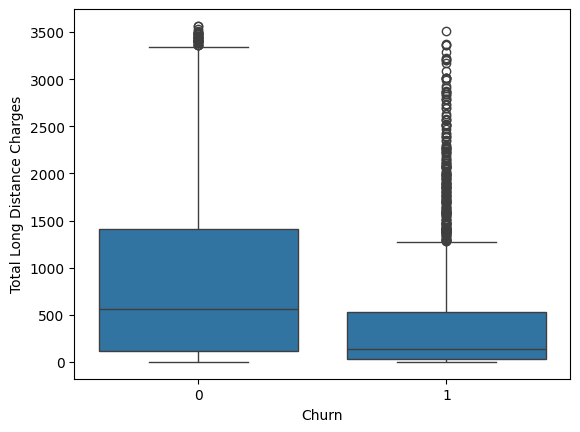

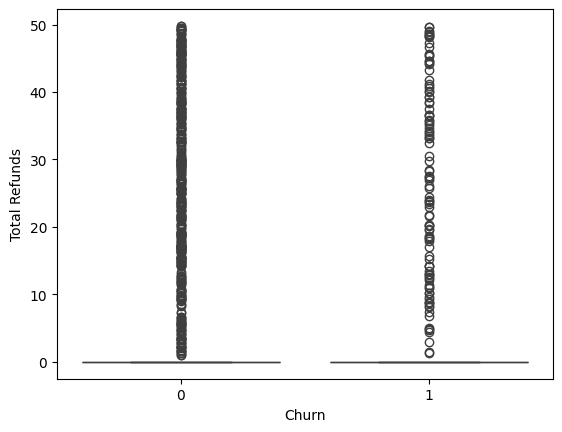

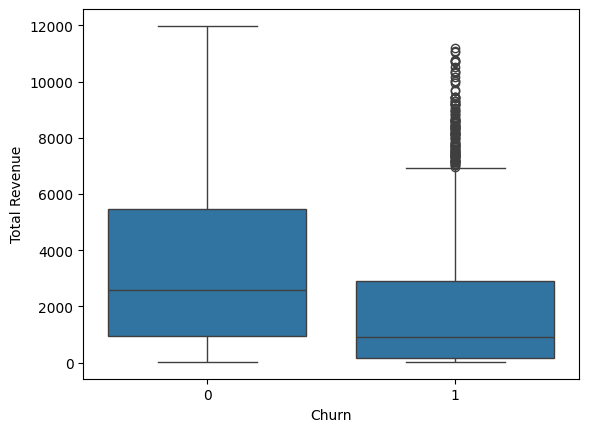

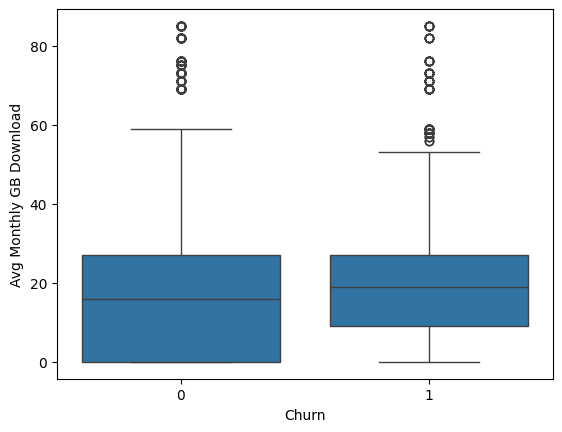

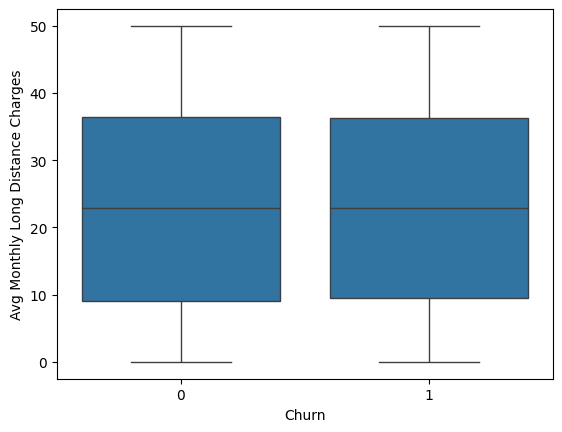

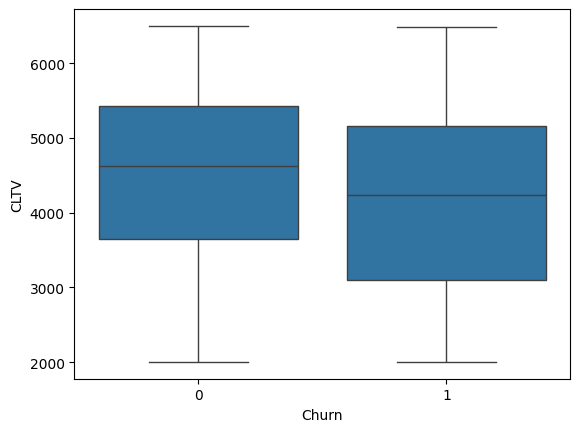

In [13]:
#Bi-variate analysis
Numerical_List=["Age","Monthly Charge","Tenure in Months","Number of Referrals",'Total Long Distance Charges','Total Refunds','Total Revenue','Avg Monthly GB Download',
'Avg Monthly Long Distance Charges',"CLTV",]
for i in Numerical_List:
  print(i,": ")
  print(pd_df.groupby("Churn")[i].describe())
  print()
  print()

for i in Numerical_List:
  sns.boxplot(x="Churn",y=i,data=pd_df)
  plt.show()

# Bivariate Analysis Insights

Bivariate analysis is performed to understand the relationship between independent features and the target variable (Churn).
By comparing churned and non-churned customers we can identify which factors influence customer churn.

# Numerical Features vs Churn
1.**Age**

*   The average age of customers who stayed is 45.34 years, while customers who churned have an average age of 49.73 years.

*   This indicates that churned customers are slightly older.

*   However, the difference is small, suggesting Age may not be a strong predictor of churn.

2.**Monthly Charges**

*   Customers who stayed pay an average monthly charge of 61.26, while churned customers pay 74.44 on average.

*   This shows that customers with higher monthly charges are more likely to churn.

*   Pricing may be a key factor influencing churn behaviour.

3.**Tenure in Months**

*   Customers who stayed have an average tenure of 37.59 months, while churned customers have only 17.97 months.

*   The median tenure for churned customers is 10 months, compared to 38 months for retained customers.

*   This suggests that new customers are more likely to churn than long-term customers.

4. **Number of Referrals**

*   Customers who stayed have an average of 2.46 referrals, while churned customers have only 0.52 referrals.

*   This indicates that customers who refer others are more engaged and loyal, and therefore less likely to churn.

5. **Total Long Distance Charges**

*   Customers who stayed have significantly higher total long-distance charges (862.95) compared to churned customers (433.91).

*   This suggests that customers who use the service more actively are less likely to churn.

6. **Total Refunds**

*   The average refunds for stayed customers (2.12) and churned customers (1.51) are relatively similar.

*   This indicates that refunds do not strongly impact churn behaviour.

7. **Total Revenue**

*   Customers who stayed generated higher average revenue (3418) compared to churned customers (1971).

*   This shows that long-term customers contribute more revenue, while churned customers usually leave earlier.

8. **Avg Monthly GB Download**

*   Churned customers download slightly more data (22.17 GB) compared to retained customers (19.91 GB).

*   This may indicate that heavy internet users may churn due to service expectations or better offers from competitors.

9. **Avg Monthly Long Distance Charges**

*   The average values for both churned and retained customers are almost the same.

*   This suggests that average monthly long-distance charges have little influence on churn.

10. **Customer Lifetime Value (CLTV)**

*   Customers who stayed have a higher average CLTV (4490) compared to churned customers (4149).

*   This shows that high-value customers tend to stay longer with the company.

Gender : 
Churn           0          1
Gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338




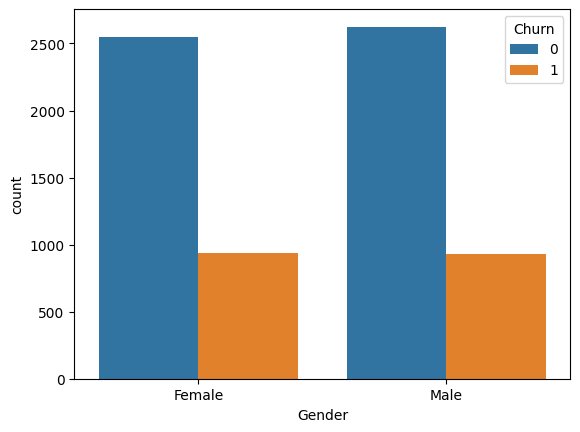


Married : 
Churn            0          1
Married                      
0        67.042021  32.957979
1        80.335097  19.664903




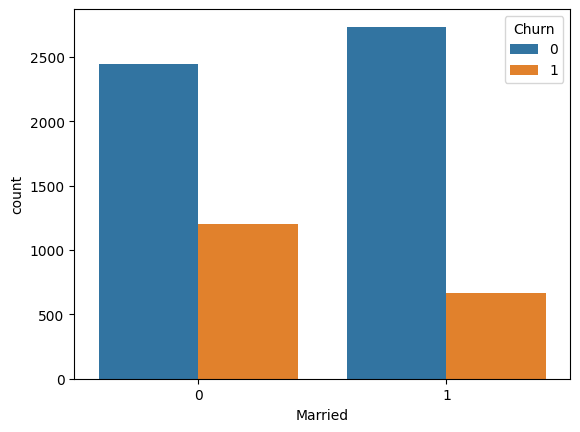


Dependents : 
Churn               0          1
Dependents                      
0           67.448301  32.551699
1           93.484942   6.515058




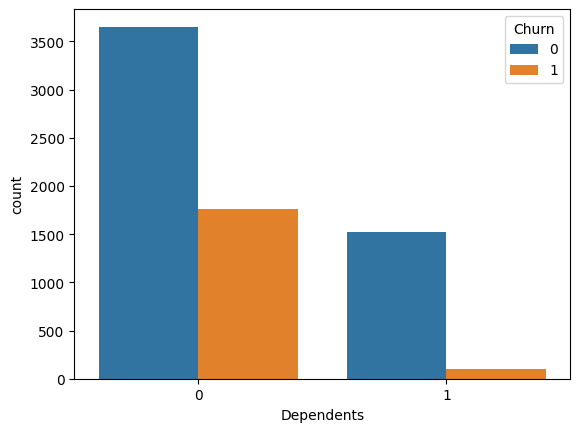


Number of Dependents : 
Churn                          0          1
Number of Dependents                       
0                      67.448301  32.551699
1                      93.128391   6.871609
2                      93.785311   6.214689
3                      94.197292   5.802708
4                      88.888889  11.111111
5                      80.000000  20.000000
6                      66.666667  33.333333
7                      50.000000  50.000000
8                     100.000000   0.000000
9                     100.000000   0.000000




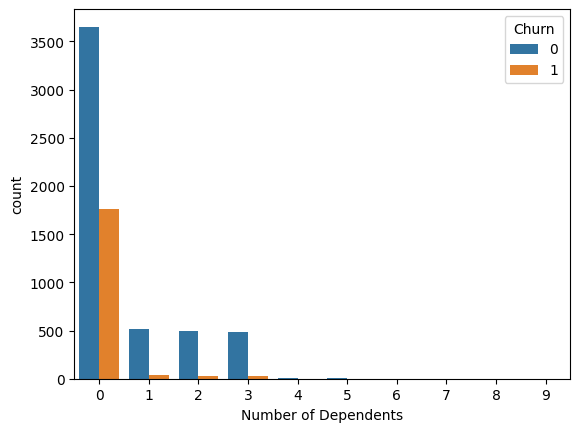


Contract : 
Churn                   0          1
Contract                            
Month-to-Month  54.155125  45.844875
One Year        89.290323  10.709677
Two Year        97.450876   2.549124




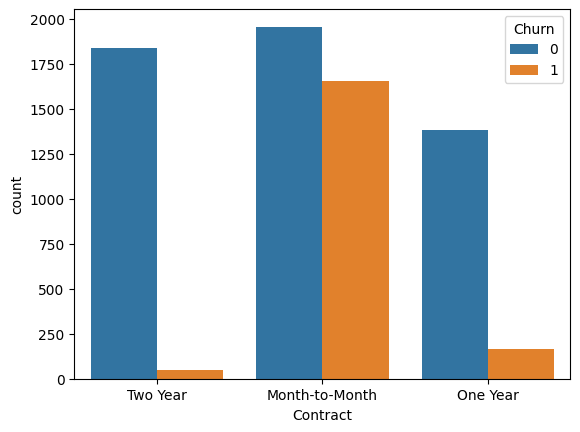


Internet Type : 
Churn                  0          1
Internet Type                      
Cable          74.337349  25.662651
DSL            81.416465  18.583535
Fiber Optic    59.275124  40.724876
Unknown        92.595020   7.404980




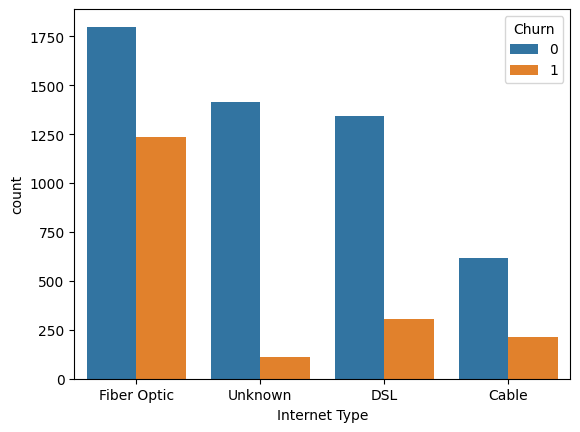


Offer : 
Churn             0          1
Offer                         
No offer  72.891411  27.108589
Offer A   93.269231   6.730769
Offer B   87.742718  12.257282
Offer C   77.108434  22.891566
Offer D   73.255814  26.744186
Offer E   47.080745  52.919255




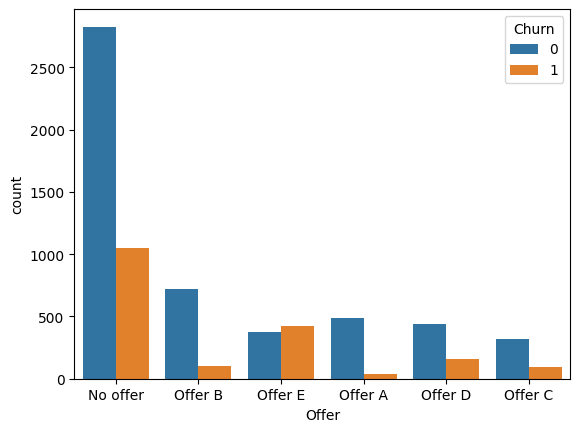


Payment Method : 
Churn                    0          1
Payment Method                       
Bank Withdrawal  66.001535  33.998465
Credit Card      85.522008  14.477992
Mailed Check     63.116883  36.883117




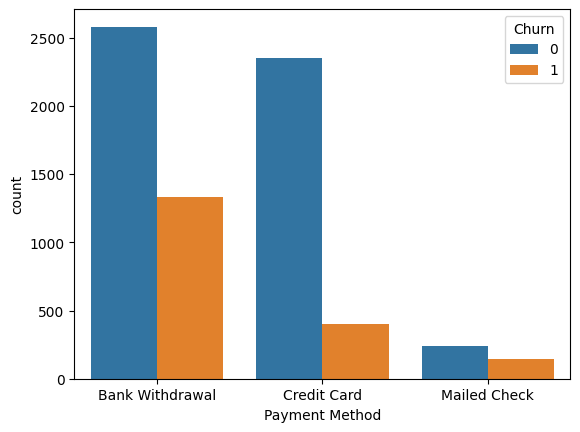


Device Protection Plan : 
Churn                           0          1
Device Protection Plan                      
0                       71.348193  28.651807
1                       77.497936  22.502064




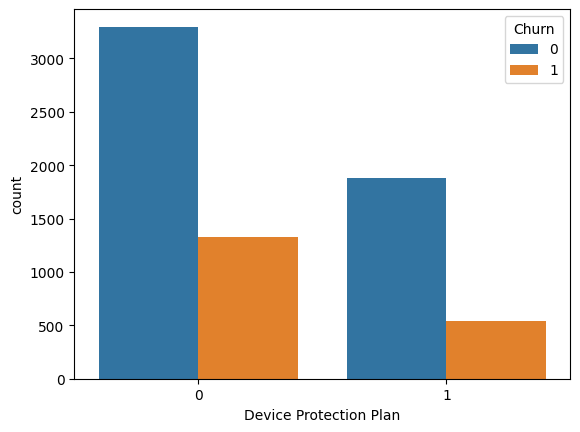


Internet Service : 
Churn                     0          1
Internet Service                      
0                 92.595020   7.404980
1                 68.171107  31.828893




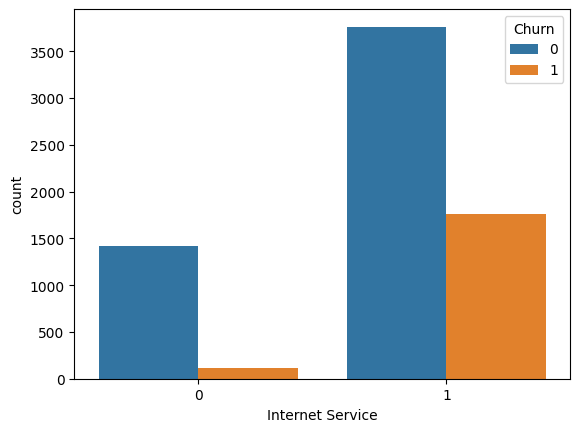


Multiple Lines : 
Churn                   0          1
Multiple Lines                      
0               74.975442  25.024558
1               71.390104  28.609896




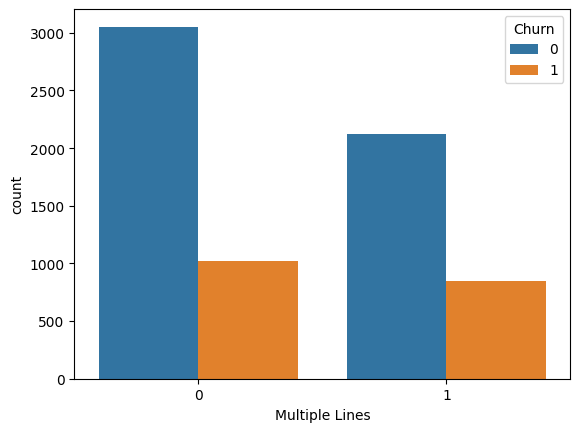


Online Backup : 
Churn                  0          1
Online Backup                      
0              70.827915  29.172085
1              78.468506  21.531494




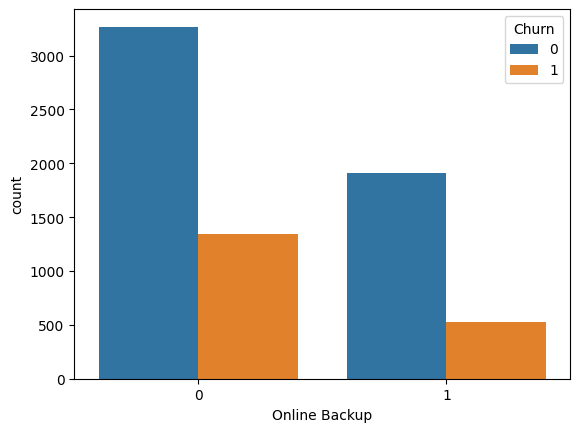


Online Security : 
Churn                    0          1
Online Security                      
0                68.670382  31.329618
1                85.388806  14.611194




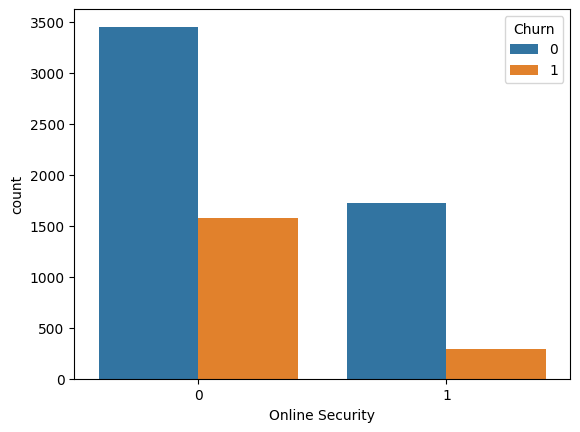


Paperless Billing : 
Churn                      0          1
Paperless Billing                      
0                  83.669916  16.330084
1                  66.434908  33.565092




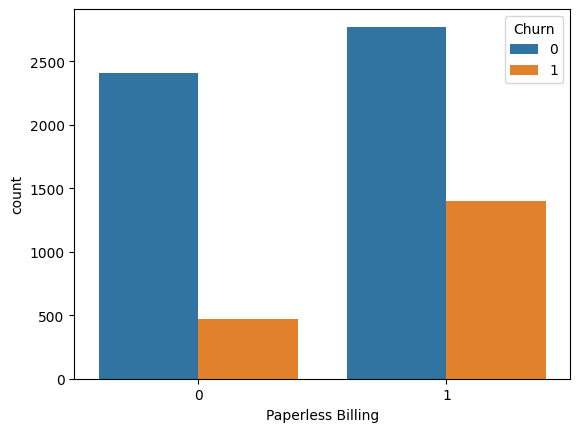


Partner : 
Churn            0          1
Partner                      
0        67.042021  32.957979
1        80.335097  19.664903




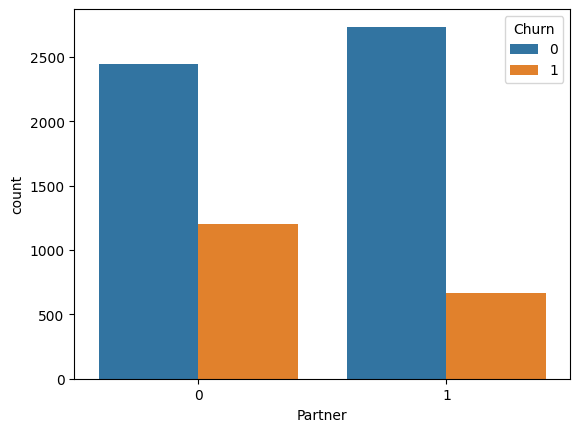


Phone Service : 
Churn                  0          1
Phone Service                      
0              75.073314  24.926686
1              73.290363  26.709637




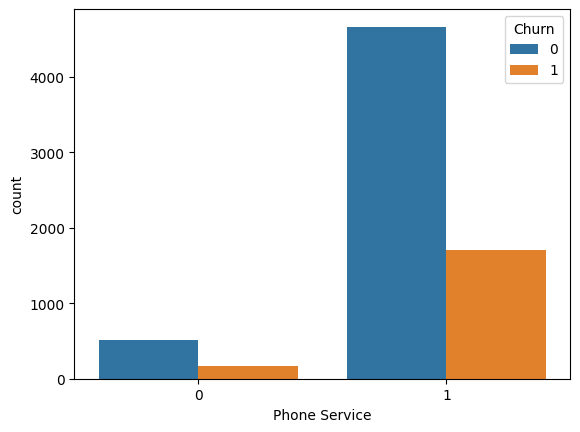


Streaming Movies : 
Churn                     0          1
Streaming Movies                      
0                 75.620506  24.379494
1                 70.058565  29.941435




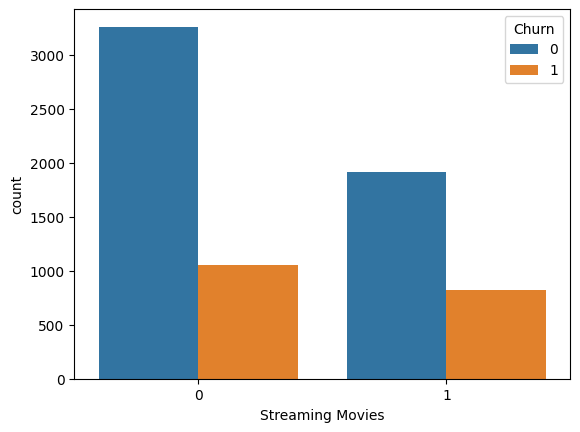


Streaming Music : 
Churn                    0          1
Streaming Music                      
0                74.950604  25.049396
1                70.739550  29.260450




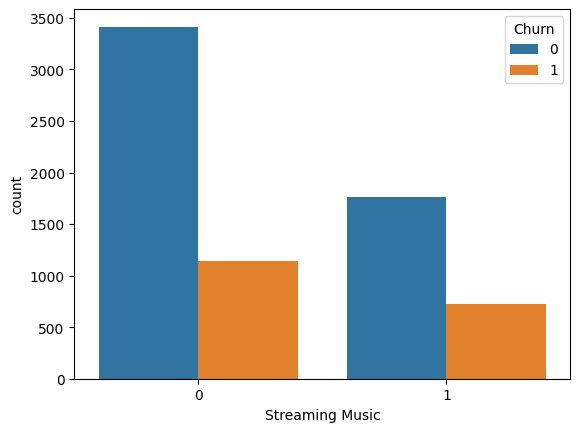


Streaming TV : 
Churn                 0          1
Streaming TV                      
0             75.668819  24.331181
1             69.929812  30.070188




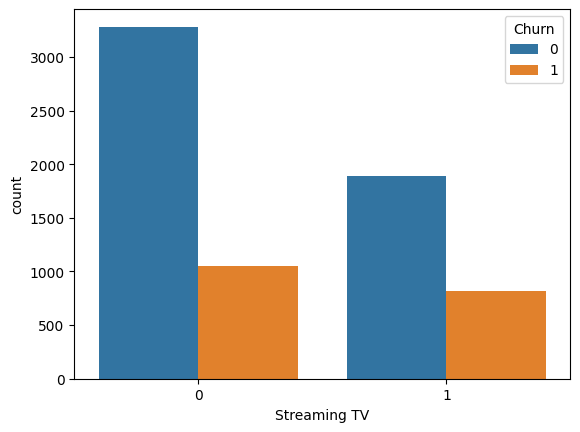


Unlimited Data : 
Churn                   0          1
Unlimited Data                      
0               84.029591  15.970409
1               68.345627  31.654373




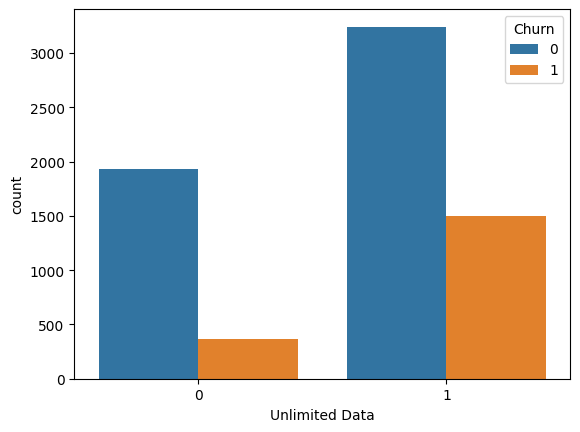

In [15]:
Categorical_List=['Gender','Married','Dependents','Number of Dependents',"Contract","Internet Type","Offer","Payment Method","Device Protection Plan",
                  "Internet Service","Multiple Lines","Online Backup","Online Security","Paperless Billing","Partner","Phone Service","Streaming Movies",
                  "Streaming Music","Streaming TV","Unlimited Data"]
for i in Categorical_List:
  print(i,": ")
  print(pd.crosstab(pd_df[i], pd_df["Churn"], normalize="index") * 100)
  print()
  print()
  sns.countplot(x=i,hue='Churn',data=pd_df)

  plt.show()
  print()

Insights from Bivariate Analysis (Categorical Features vs Churn)
1.**Gender**

The churn percentage for female customers is 26.92% and for male customers is 26.16%.

The difference between the two is very small.

This indicates that gender does not significantly influence customer churn.

2.**Married**

Customers who are not married have a churn rate of 32.95%, while married customers have a churn rate of 19.66%.

This shows that married customers are more likely to stay with the telecom service.

Married customers may prefer stability in their service providers.

3.**Dependents**

Customers without dependents have a churn rate of 32.55%, while customers with dependents have only 6.51% churn.

This indicates that customers with dependents are far less likely to churn.

Families tend to stay with the same telecom provider for longer periods.

4.**Number of Dependents**

Customers with 0 dependents have the highest churn rate (32.55%).

Customers with 1–3 dependents have very low churn rates (around 5–7%).

This further confirms that family customers are more loyal and less likely to switch providers.

5.**Contract**

Customers with Month-to-Month contracts have the highest churn rate (45.84%).

Customers with One-Year contracts have a churn rate of 10.70%.

Customers with Two-Year contracts have the lowest churn rate (2.54%).

This indicates that long-term contracts significantly reduce customer churn.

6.**Internet Type**

Customers using Fiber Optic internet have the highest churn rate (40.72%).

Customers using DSL have lower churn (18.58%).

Customers with unknown or no internet service have very low churn (7.40%).

This may indicate that fiber optic users have higher expectations or face service issues.

7.**Offer**

Customers with Offer A and Offer B have very low churn rates (6.7% and 12.25%).

Customers with Offer E have the highest churn rate (52.91%).

Customers with no offer have a churn rate of 27.10%.

This suggests that promotional offers can strongly influence customer retention.

8.**Payment Method**

Customers using Credit Card payments have the lowest churn rate (14.47%).

Customers using Bank Withdrawal have a churn rate of 33.99%.

Customers using Mailed Check have the highest churn rate (36.88%).

This indicates that automatic digital payments are associated with better customer retention.

9.**Device Protection Plan**

Customers without device protection have a churn rate of 28.65%.

Customers with device protection have a lower churn rate of 22.50%.

This suggests that customers who purchase additional services are slightly more loyal.

10.**Internet Service**

Customers without internet service have a very low churn rate (7.40%).

Customers with internet service have a higher churn rate (31.82%).

This may indicate that internet-related issues could influence customer churn.

11.**Multiple Lines**

Customers without multiple lines have a churn rate of 25.02%.

Customers with multiple lines have a churn rate of 28.60%.

The difference is small, suggesting multiple lines do not strongly impact churn.

12.**Online Backup**

Customers without online backup have a churn rate of 29.17%.

Customers with online backup have a lower churn rate of 21.53%.

This indicates that customers who use additional services tend to stay longer with the provider.

13.**Online Security**

Customers without online security have a churn rate of 31.33%.

Customers with online security have a much lower churn rate of 14.61%.

This suggests that security services improve customer retention.

14.**Paperless Billing**

Customers without paperless billing have a churn rate of 16.33%.

Customers with paperless billing have a churn rate of 33.56%.

This indicates that customers using paperless billing may change providers more frequently.

15.**Partner**

Customers without a partner have a churn rate of 32.95%.

Customers with a partner have a churn rate of 19.66%.

This again shows that family-based customers are more stable and less likely to churn.

16.**Phone Service**

Customers without phone service have a churn rate of 24.92%.

Customers with phone service have a churn rate of 26.70%.

The difference is small, indicating phone service has limited impact on churn.

17.**Streaming Movies**

Customers without streaming movies have a churn rate of 24.37%.

Customers with streaming movies have a churn rate of 29.94%.

This suggests that streaming services do not strongly prevent churn.

18.**Streaming Music**

Customers without streaming music have a churn rate of 25.04%.

Customers with streaming music have a churn rate of 29.26%.

The difference is moderate and may indicate slightly higher churn among streaming users.

19.**Streaming TV**

Customers without streaming TV have a churn rate of 24.33%.

Customers with streaming TV have a churn rate of 30.07%.

This suggests streaming TV users churn slightly more.

20.**Unlimited Data**

Customers without unlimited data have a churn rate of 15.97%.

Customers with unlimited data have a much higher churn rate of 31.65%.

This indicates that heavy data users may switch providers more frequently, possibly looking for better plans or pricing.

**Key Observations from Categorical Analysis**

The most important factors affecting churn appear to be:

Contract type

Dependents

Online security

Offers

Payment method

Unlimited data

**Key Observations from Numerical Analysis**

The most important factors influencing churn appear to be:

Monthly Charges

Tenure

Number of Referrals

Total Revenue

Total Long Distance Charges

In [17]:
corr_matrix = pd_df.corr(numeric_only=True)
corr_matrix
pd_df.shape

(7043, 39)

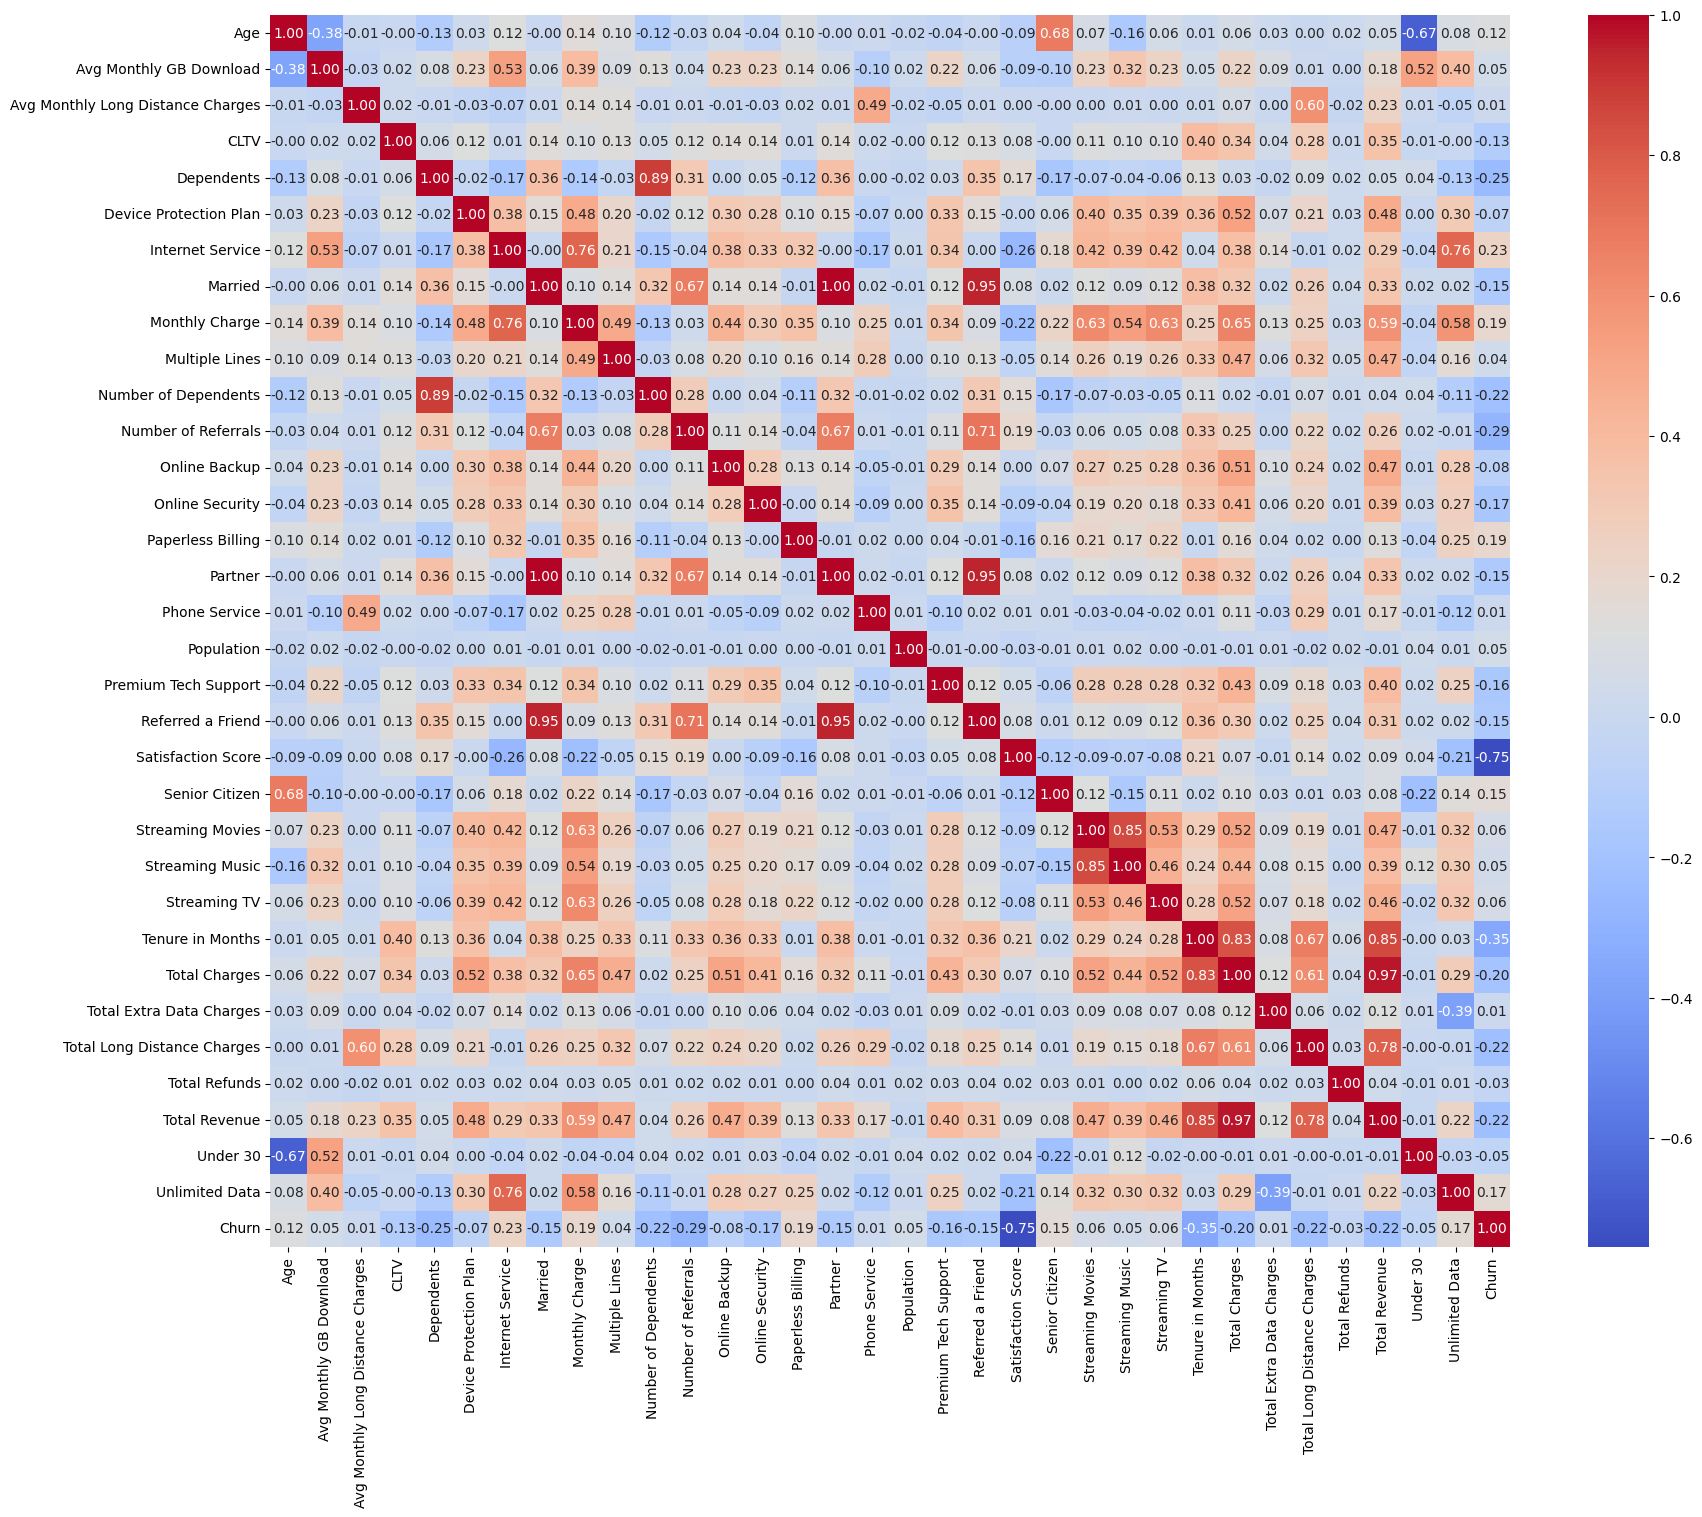

In [18]:
plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()